
# Problem 1

My approach uses the T5-small model from Hugging Face. The setup is essentially the same as Assignment 7 Q4 with these changes:
- Use the tokenizer that comes with the T5 model to simplify reading the data in
- The training loop fine-tunes the pretrained weights on the SQuAD dataset so that the model learns to generate answers from question and context inputs.  
- Abbreviated context is included in the training loop (I did not include context info in Assignment 7 Q4)
- The `eval` logic is simplified by taking advantage of the model's included `generate` function

### References 
I found these sources helpful in figuring out how to adapt the training loop and work with the T5 model:
- https://huggingface.co/learn/llm-course/chapter3/4
- https://huggingface.co/docs/transformers/tasks/translation


Ensure I'm logged into Hugging Face

In [1]:
from huggingface_hub import HfApi
api = HfApi()
try:
    who = api.whoami()
    print("Logged in as:", who["name"])
except Exception as e:
    print("Not authenticated:", e)

Logged in as: InfestedCoder


## Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72

import os
import random
import numpy as np
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import transformers
from transformers import T5Tokenizer, T5ForConditionalGeneration

MODEL_PATH= 'EP_models/'
os.environ['HF_HOME']= MODEL_PATH  # before import transformers
os.environ['HF_DATASETS_CACHE']= 'EP_datasets/'  # dataset cache

Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"torch version= {torch.__version__}")
print(f"transformers version= {transformers.__version__}")
print(f"device= {Device}")

torch version= 2.10.0
transformers version= 5.0.0
device= cpu


## Hyperparameters 

In [3]:
MODEL_NAME = 't5-small'

BATCH_SIZE = 8
EPOCHS = 2
LR = 2e-4

MAX_INPUT_LEN = 256
MAX_OUTPUT_LEN = 32

TRAIN_SIZE = 4000
VAL_SIZE = 500

CONTEXT_CHARS = 300

Save part of the dataset to evaluate the model

In [4]:
Dataset_squad = load_dataset('squad', split=f'train[:{TRAIN_SIZE}]')

Dataset_squad_val = load_dataset('squad', split=f'validation[:{VAL_SIZE}]')

print(f"#train= {len(Dataset_squad)}")
print(f"#val=   {len(Dataset_squad_val)}")
print(Dataset_squad[0].keys())

#train= 4000
#val=   500
dict_keys(['id', 'title', 'context', 'question', 'answers'])


This class below is simplified from the Assignment 7 by using the model's tokenizer. 

Context is stripped to only be the first few hundred characters. 

For T5 training we supply three tensors.

- `input_ids` are token IDs representing the input sequence "question: {question} context: {context}".
- `attention_mask` indicates which tokens are real (1) versus padding (0), preventing the model from attending to padding tokens.
- `labels` are token IDs representing the target sequence (the answer). Padding tokens in the labels are replaced with -100 so they are ignored when computing the training loss.

### Reference
This doc was helpful in understanding the three tensors:
https://huggingface.co/docs/transformers/model_doc/t5

In [5]:
class QADatasetT5(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_input_len=256, max_output_len=32, context_chars=300):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_output_len = max_output_len
        self.context_chars = context_chars

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        ex = self.dataset[idx]

        question = ex['question'].strip()

        # Only use the first part of the context
        context = ex['context'].strip()[:self.context_chars]

        # Use the first listed answer for training
        answer_text = ex['answers']['text'][0].strip()
        
        input_text = f"question: {question}  context: {context}"
        target_text = answer_text

        enc = self.tokenizer(
            input_text,
            max_length=self.max_input_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        dec = self.tokenizer(
            target_text,
            max_length=self.max_output_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)
        labels = dec['input_ids'].squeeze(0)

        # ignore padding tokens in the loss
        labels[labels == self.tokenizer.pad_token_id] = -100

        return input_ids, attention_mask, labels

In [6]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(Device)

Dataset_train = QADatasetT5(
    Dataset_squad,
    tokenizer,
    max_input_len=MAX_INPUT_LEN,
    max_output_len=MAX_OUTPUT_LEN,
    context_chars=CONTEXT_CHARS
)

Dloader_train = DataLoader(Dataset_train, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())

print(f"#train batches= {len(Dloader_train)}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

#train batches= 500


In [7]:
input_ids, attention_mask, labels = next(iter(Dloader_train))

print(f"input_ids.shape = {input_ids.shape}")
print(f"attention_mask.shape = {attention_mask.shape}")
print(f"labels.shape = {labels.shape}")

sample_in = tokenizer.decode(input_ids[0], skip_special_tokens=True)
sample_lab_ids = labels[0].clone()
sample_lab_ids[sample_lab_ids == -100] = tokenizer.pad_token_id
sample_out = tokenizer.decode(sample_lab_ids, skip_special_tokens=True)

print("\nSample input:\n")
print(sample_in)

print("\nSample target:\n")
print(sample_out)

input_ids.shape = torch.Size([8, 256])
attention_mask.shape = torch.Size([8, 256])
labels.shape = torch.Size([8, 32])

Sample input:

question: What year was Jeannette Rankin vote against war the first time? context: In 1940, Jeannette Rankin had once again been elected to Congress, and in 1941, as she did in 1917, she voted against the United States' declaration of war. This time she was the only vote against the war, and in the wake of public outcry over her vote, she required police protection for a time. Oth

Sample target:

1917


In [8]:
def train(model, epochs=2, info=True):
    import sys

    optim = torch.optim.AdamW(model.parameters(), lr=LR)

    model.train()
    losses = []
    N = len(Dloader_train)
    
    for e in range(epochs):
        for b, (input_ids, attention_mask, labels) in enumerate(Dloader_train):
            input_ids = input_ids.to(Device, non_blocking=True)
            attention_mask = attention_mask.to(Device, non_blocking=True)
            labels = labels.to(Device, non_blocking=True)

            optim.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optim.step()
            
            losses.append(loss.item())

            if info:
                sys.stderr.write(f"\rEpoch: {e+1}/{epochs} | Iteration: {b:4d}/{N:4d} | Loss: {loss.item():3.2f}")
                sys.stderr.flush()
    
    return losses

In [ ]:
%%time

train_losses = train(model, epochs=EPOCHS, info=True)

Epoch: 1/2 | Iteration:   73/ 500 | Loss: 1.91

I was curious what the loss looks like when fine-tuning a pre-trained model, so I included this chart

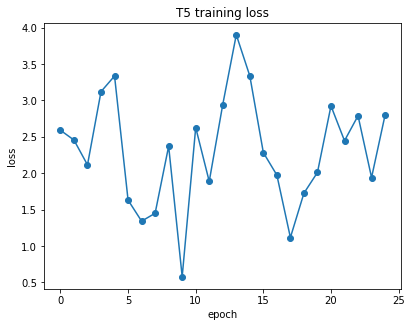

In [14]:
plt.plot(train_losses, marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('T5 training loss')
plt.show()

We use the model's `tokenizer` again to get the input format right and then use the model's `generate` function ti get the answer.

In [15]:
def generate_answer(model, tokenizer, question, context, max_input_len=256, max_output_len=32):
    model.eval()

    input_text = f"question: {question}  context: {context}"
    enc = tokenizer(
        input_text,
        max_length=max_input_len,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = enc['input_ids'].to(Device)
    attention_mask = enc['attention_mask'].to(Device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_output_len,
            num_beams=4,
            early_stopping=True
        )

    pred = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return pred

Pull some random questions from our evaluation dataset and see how good the model is at generating the answers

In [16]:
def eval_rnd(model, tokenizer, n=5):
    model.eval()

    for _ in range(n):
        i = random.randint(0, len(Dataset_squad_val) - 1)
        ex = Dataset_squad_val[i]

        question = ex['question'].strip()
        context = ex['context'].strip()[:CONTEXT_CHARS]
        true_answer = ex['answers']['text'][0].strip()        

        pred_answer = generate_answer(
            model,
            tokenizer,
            question,
            context,
            max_input_len=MAX_INPUT_LEN,
            max_output_len=MAX_OUTPUT_LEN
        )

        print("="*80)
        print(f"QUESTION: {question}")
        print(f"\nCONTEXT: {context}")
        print(f"\nTRUE: {true_answer}")
        print(f"PRED: {pred_answer}")
        print()

In [18]:
eval_rnd(model, tokenizer, n=5)

QUESTION: Who did the Broncos prevent from going to the Super Bowl?

CONTEXT: The Panthers finished the regular season with a 15–1 record, and quarterback Cam Newton was named the NFL Most Valuable Player (MVP). They defeated the Arizona Cardinals 49–15 in the NFC Championship Game and advanced to their second Super Bowl appearance since the franchise was founded in 1995. The

TRUE: New England Patriots
PRED: the Arizona Cardinals

QUESTION: Who was the Most Valuable Player of Super Bowl 50?

CONTEXT: The Broncos took an early lead in Super Bowl 50 and never trailed. Newton was limited by Denver's defense, which sacked him seven times and forced him into three turnovers, including a fumble which they recovered for a touchdown. Denver linebacker Von Miller was named Super Bowl MVP, recording five 

TRUE: Von Miller
PRED: Von Miller

QUESTION: What city did Super Bowl 50 take place in?

CONTEXT: Super Bowl 50 was an American football game to determine the champion of the National Footbal

This looks pretty good. The first answer is wrong, but it's still giving a pro football team. 

TRUE: New England Patriots
PRED: the Arizona Cardinals

Similarly, the answer about what city the super bowl 50 was in swaps US cities

TRUE: Santa Clara
PRED: New York

We can do the same cosine similarity test we did in assignment 7

Below, we're able to re-use most of what we had in assignment 7 and can even clean some things up by using the model's `tokenizer` again.  

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import random

def generate_answer_ids(model, tokenizer, question, context, max_input_len=256, max_output_len=32):
    model.eval()

    input_text = f"question: {question} context: {context}"

    enc = tokenizer(
        input_text,
        max_length=max_input_len,
        truncation=True,
        return_tensors='pt'
    )

    input_ids = enc['input_ids'].to(Device)
    attention_mask = enc['attention_mask'].to(Device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_output_len,
            num_beams=4,
            early_stopping=True
        )

    return output_ids[0].detach().cpu().tolist()


def seq_to_bow_vector(token_ids, vocab_size, ignore_tokens=None):
    token_ids = [tid for tid in token_ids if 0 <= tid < vocab_size]

    vec = np.bincount(token_ids, minlength=vocab_size).astype(np.float32)

    if ignore_tokens:
        for t in ignore_tokens:
            if 0 <= t < vocab_size:
                vec[t] = 0.0

    return torch.tensor(vec, dtype=torch.float32)

def score_one_example_t5(sample_idx, model, tokenizer, dataset):
    ex = dataset[sample_idx]

    question = ex['question'].strip()
    context = ex['context'].strip()[:CONTEXT_CHARS]
    true_answer = ex['answers']['text'][0].strip()

    pred_ids = generate_answer_ids(
        model,
        tokenizer,
        question,
        context,
        max_input_len=MAX_INPUT_LEN,
        max_output_len=MAX_OUTPUT_LEN
    )

    target_ids = tokenizer(
        true_answer,
        max_length=MAX_OUTPUT_LEN,
        truncation=True,
        return_tensors='pt'
    )['input_ids'].squeeze(0).tolist()

    ignore_tokens = {
        tokenizer.pad_token_id,
        tokenizer.eos_token_id
    }

    ignore_tokens = {t for t in ignore_tokens if t is not None}

    vocab_size = tokenizer.vocab_size

    target_vec = seq_to_bow_vector(target_ids, vocab_size, ignore_tokens=ignore_tokens)
    pred_vec = seq_to_bow_vector(pred_ids, vocab_size, ignore_tokens=ignore_tokens)

    score = F.cosine_similarity(
        target_vec.unsqueeze(0),
        pred_vec.unsqueeze(0)
    ).item()

    pred_text = tokenizer.decode(pred_ids, skip_special_tokens=True)

    return {
        "sample_idx": sample_idx,
        "target": true_answer,
        "prediction": pred_text,
        "cosine_similarity": score
    }

def evaluate_cosine_similarity_t5(model, tokenizer, dataset, n_samples=100):
    scores = []

    for _ in range(n_samples):
        sample_idx = random.randint(0, len(dataset) - 1)
        result = score_one_example_t5(sample_idx, model, tokenizer, dataset)
        scores.append(result["cosine_similarity"])

        print(f"target:     {result['target']}")
        print(f"prediction: {result['prediction']}")
        print(f"cosine:     {result['cosine_similarity']:.4f}")
        print("-" * 60)

    mean_score = float(np.mean(scores))
    median_score = float(np.median(scores))

    print(f"\nAverage cosine similarity over {n_samples} samples: {mean_score:.4f}")
    print(f"Median cosine similarity over {n_samples} samples:  {median_score:.4f}")

    return mean_score, median_score, scores

In [26]:
mean_score, median_score, scores = evaluate_cosine_similarity_t5(
    model,
    tokenizer,
    Dataset_squad_val,
    n_samples=50
)

target:     gold
prediction: yellow
cosine:     0.0000
------------------------------------------------------------
target:     New England Patriots
prediction: the Arizona Cardinals
cosine:     0.2500
------------------------------------------------------------
target:     Cam Newton
prediction: Cam Newton
cosine:     1.0000
------------------------------------------------------------
target:     three
prediction: three
cosine:     1.0000
------------------------------------------------------------
target:     New England Patriots
prediction: the Arizona Cardinals
cosine:     0.2500
------------------------------------------------------------
target:     Denver Broncos
prediction: Colorado Panthers
cosine:     0.2582
------------------------------------------------------------
target:     Beyoncé
prediction: Bruno Mars
cosine:     0.0000
------------------------------------------------------------
target:     Von Miller
prediction: Von Miller
cosine:     1.0000
-----------------------

What if we just use the original T5 model?

In [25]:
original_t5_model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(Device)


mean_score, median_score, scores = evaluate_cosine_similarity_t5(
    original_t5_model,
    tokenizer,
    Dataset_squad_val,
    n_samples=50
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

target:     "golden anniversary"
prediction: American football game
cosine:     0.0000
------------------------------------------------------------
target:     two
prediction: five
cosine:     0.0000
------------------------------------------------------------
target:     Von Miller
prediction: Von Miller
cosine:     1.0000
------------------------------------------------------------
target:     CBS
prediction: CBS
cosine:     1.0000
------------------------------------------------------------
target:     Levi's Stadium
prediction: National Football League
cosine:     0.0000
------------------------------------------------------------
target:     Beyoncé
prediction: Bruno Mars
cosine:     0.0000
------------------------------------------------------------
target:     linebacker
prediction: MVP
cosine:     0.0000
------------------------------------------------------------
target:     Cam Newton
prediction: Cam Newton
cosine:     1.0000
--------------------------------------------------